In [10]:
# ------ Module Import ------ #
import os
import time
import pickle
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report,
    accuracy_score, confusion_matrix, f1_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline
import umap.umap_ as umap

In [2]:
RAND_SEED = 7 
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "Data")
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), "Results")
PLOT_DIR = os.path.join(os.path.dirname(os.getcwd()), "Plots")
MODEL_DIR = os.path.join(os.path.dirname(os.getcwd()), "Models")

for d in [DATA_DIR, RESULTS_DIR, PLOT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

In [3]:
#Loading the stratified split dataset

spv_dataset = joblib.load(os.path.join(DATA_DIR, "spv_split_dataset_100hvg.pkl"))
print(f"Loaded dataset with {len(spv_dataset['y_train'])} train samples")

Loaded dataset with 53825 train samples


In [6]:
#Extracting the dataset components
X_train = spv_dataset["X_train"]
X_val = spv_dataset["X_val"]
X_test = spv_dataset["X_test"]
y_train = spv_dataset["y_train"]
y_val = spv_dataset["y_val"]
y_test = spv_dataset["y_test"]
meta_train = spv_dataset["meta_train"]
meta_val = spv_dataset["meta_val"]
meta_test = spv_dataset["meta_test"]
label_encoder = spv_dataset["label_encoder"]
class_weights = spv_dataset["class_weights"]
feature_genes = spv_dataset["feature_genes"]

print("Dataset Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nClass Names, Encodings, Split Counts and Weights:")
for i, class_name in enumerate(label_encoder.classes_):
    count_train = np.sum(y_train == i)
    count_val = np.sum(y_val == i)
    count_test = np.sum(y_test == i)
    total_count = count_train + count_val + count_test
    weight = class_weights.get(i, "N/A")
    print(f"Class {i:<2} = {class_name:<15} | Train: {count_train:<5} | Val: {count_val:<5} | Test: {count_test:<5} | Total: {total_count:<5} | Weight: {weight:.4f}")

print("\nFeature dtype sanity check:")
print(f"X_train dtype: {X_train.dtypes.unique() if hasattr(X_train, 'dtypes') else X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")

Dataset Shapes:
X_train: (53825, 100)
X_val:   (11534, 100)
X_test:  (11534, 100)

Class Names, Encodings, Split Counts and Weights:
Class 0  = B intermediate  | Train: 2438  | Val: 523   | Test: 522   | Total: 3483  | Weight: 1.5770
Class 1  = B memory        | Train: 1535  | Val: 329   | Test: 329   | Total: 2193  | Weight: 2.5047
Class 2  = B naive         | Train: 5360  | Val: 1148  | Test: 1148  | Total: 7656  | Weight: 0.7173
Class 3  = CD14 Mono       | Train: 6769  | Val: 1450  | Test: 1451  | Total: 9670  | Weight: 0.5680
Class 4  = CD16 Mono       | Train: 4445  | Val: 953   | Test: 953   | Total: 6351  | Weight: 0.8649
Class 5  = CD4 Naive       | Train: 4980  | Val: 1067  | Test: 1067  | Total: 7114  | Weight: 0.7720
Class 6  = CD4 TCM         | Train: 6475  | Val: 1387  | Test: 1388  | Total: 9250  | Weight: 0.5938
Class 7  = CD4 TEM         | Train: 935   | Val: 200   | Test: 200   | Total: 1335  | Weight: 4.1119
Class 8  = CD8 Naive       | Train: 6350  | Val: 1361  | Te

In [13]:
from sklearn.frozen import FrozenEstimator

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeClassifier(
        alpha=1.0,
        class_weight=class_weights,
        random_state=RAND_SEED
    ))
])

print("Training Ridge classifier...")
ridge_pipeline.fit(X_train, y_train)

y_val_pred_ridge = ridge_pipeline.predict(X_val)

# RidgeClassifier doesn't output probabilities natively — calibrate to get them
calibrated_ridge = CalibratedClassifierCV(
    FrozenEstimator(ridge_pipeline),
    method="sigmoid"
)
calibrated_ridge.fit(X_val, y_val)
y_val_proba_ridge = calibrated_ridge.predict_proba(X_val)

print("\nRidge Classifier - Classification Report")
print(classification_report(y_val, y_val_pred_ridge, target_names=label_encoder.classes_))

Training Ridge classifier...

Ridge Classifier - Classification Report
                 precision    recall  f1-score   support

 B intermediate       0.64      0.55      0.59       523
       B memory       0.53      0.58      0.56       329
        B naive       0.84      0.84      0.84      1148
      CD14 Mono       0.96      0.95      0.96      1450
      CD16 Mono       0.94      0.97      0.95       953
      CD4 Naive       0.59      0.74      0.66      1067
        CD4 TCM       0.90      0.38      0.53      1387
        CD4 TEM       0.34      0.68      0.45       200
      CD8 Naive       0.75      0.84      0.79      1361
        CD8 TCM       0.59      0.63      0.61       360
        CD8 TEM       0.94      0.81      0.87      1296
Dendritic cells       0.96      0.95      0.96       394
             NK       0.95      0.98      0.97       913
           Treg       0.26      0.82      0.39       153

       accuracy                           0.78     11534
      macro avg

In [15]:
# Calculate overall accuracy
accuracy = accuracy_score(y_val, y_val_pred_ridge)
weighted_f1 = f1_score(y_val, y_val_pred_ridge, average="weighted")
macro_f1 = f1_score(y_val, y_val_pred_ridge, average="macro")

print(f"\nRidge Classifier Performance:")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Per-class performance
class_report = classification_report(
    y_val, y_val_pred_ridge,
    target_names=label_encoder.classes_,
    output_dict=True
)
class_metrics = pd.DataFrame(class_report).T
class_metrics = class_metrics.sort_values(by="f1-score", ascending=False)

# Drop summary rows by name (robust to sort order, unlike positional slicing)
summary_rows = ["accuracy", "macro avg", "weighted avg"]
class_metrics_only = class_metrics.drop(index=[r for r in summary_rows if r in class_metrics.index])

print("\nTop 5 best-classified cell types:")
print(class_metrics_only.head(5)[["precision", "recall", "f1-score", "support"]])

print("\nBottom 5 worst-classified cell types:")
print(class_metrics_only.tail(5)[["precision", "recall", "f1-score", "support"]])


Ridge Classifier Performance:
Overall Accuracy: 0.7817
Weighted F1-Score: 0.7829
Macro F1-Score: 0.7237

Top 5 best-classified cell types:
                 precision    recall  f1-score  support
NK                0.954255  0.982475  0.968160    913.0
Dendritic cells   0.959079  0.951777  0.955414    394.0
CD14 Mono         0.957064  0.953103  0.955079   1450.0
CD16 Mono         0.935091  0.967471  0.951006    953.0
CD8 TEM           0.943089  0.805556  0.868914   1296.0

Bottom 5 worst-classified cell types:
                precision    recall  f1-score  support
B intermediate   0.640798  0.552581  0.593429    523.0
B memory         0.531856  0.583587  0.556522    329.0
CD4 TCM          0.898451  0.376352  0.530488   1387.0
CD4 TEM          0.339196  0.675000  0.451505    200.0
Treg             0.259794  0.823529  0.394984    153.0


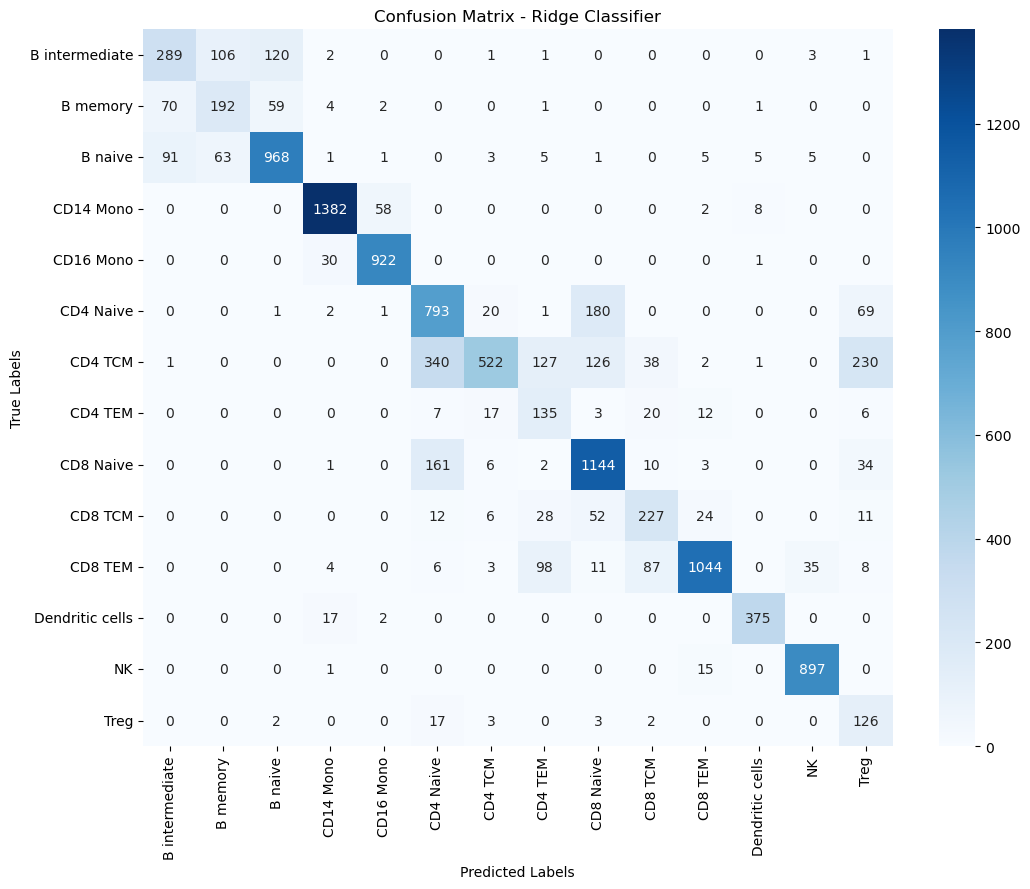

In [16]:
cm_ridge = confusion_matrix(y_val, y_val_pred_ridge)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_ridge, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Ridge Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "confusion_matrix_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

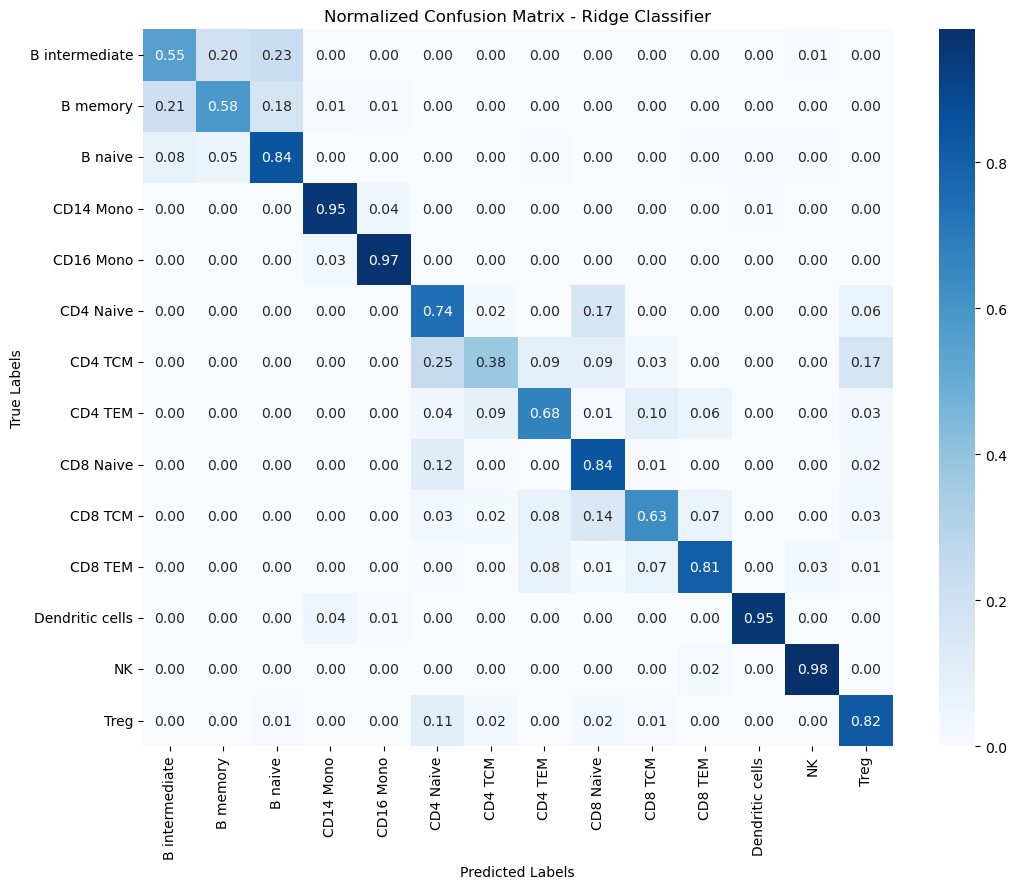

In [17]:
cm_ridge_norm = cm_ridge.astype("float") / cm_ridge.sum(axis=1, keepdims=True)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_ridge_norm, annot=True, 
    fmt=".2f", 
    cmap="Blues",
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix - Ridge Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "normalized_confusion_matrix_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

The confusion matrix reveals two distinct, biologically interpretable error patterns among the poorly-performing classes. CD4 TCM's low recall (0.38) is driven by scattering across multiple related T-cell states — 25% of true CD4 TCM cells are misclassified as CD4 Naive, 17% as Treg — rather than a single dominant confusion, consistent with CD4 TCM's intermediate transcriptional position between naive and effector states. Treg's low precision (0.26), meanwhile, traces predominantly to a single source: 17% of true CD4 TCM cells (230 of 1387) are misclassified as Treg, making CD4 TCM the dominant contributor to Treg's false positives. The B-cell subtypes (B intermediate, B memory, B naive) show a symmetric three-way confusion pattern, consistent with their known transcriptional similarity established during EDA. In contrast, well-separated lineages — NK (0.98), CD16 Mono (0.97), Dendritic cells (0.95), CD14 Mono (0.95) — show near-perfect diagonal dominance with minimal cross-contamination.

In [18]:
# Binarize the validation labels for one-vs-rest ROC/PR curves
y_val_bin = label_binarize(y_val, classes=np.unique(y_train))
n_classes = y_val_bin.shape[1]

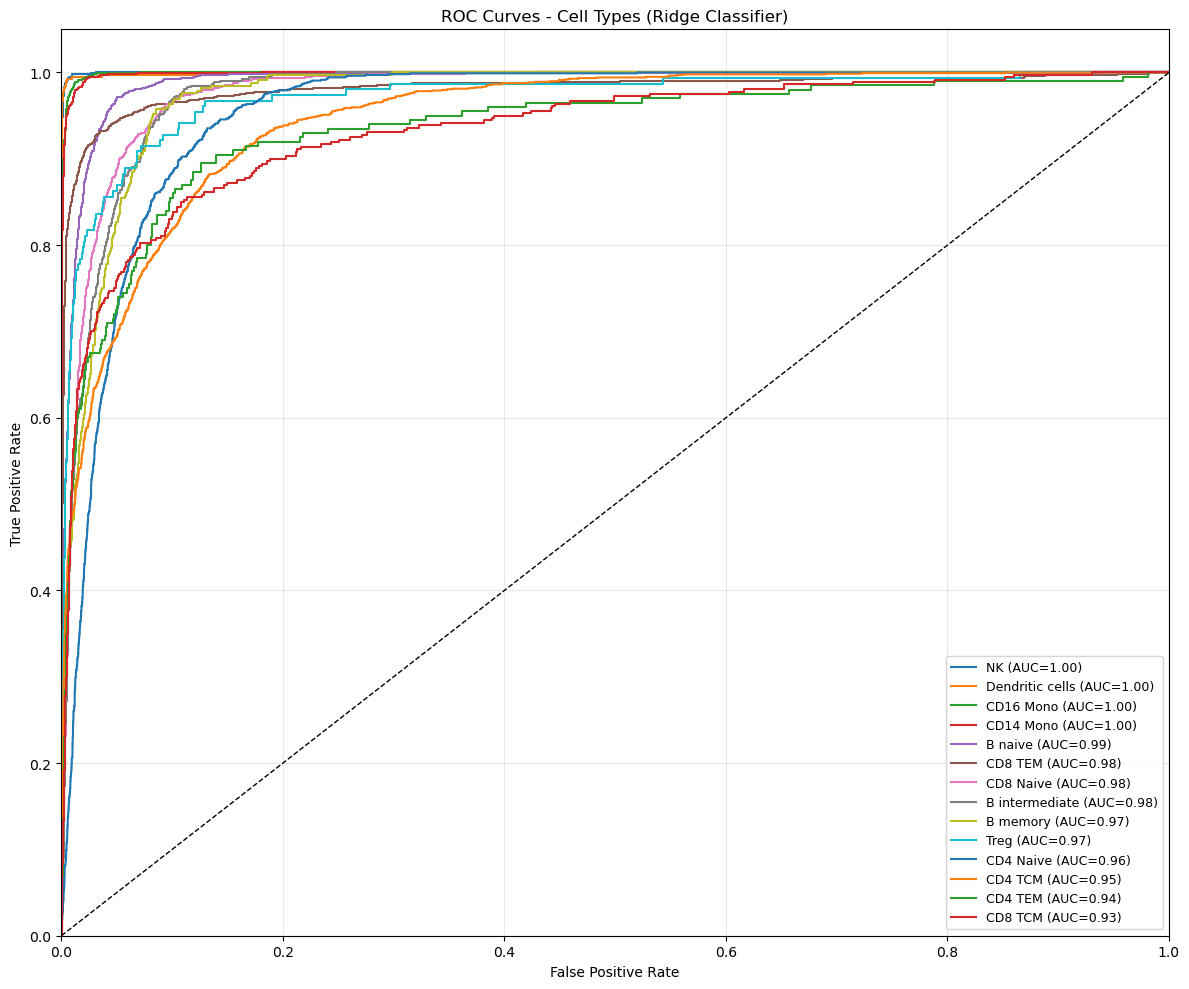

In [22]:
# ROC Curves : one per cell type, colored/labeled individually
plt.figure(figsize=(12, 10))

roc_results = []
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_proba_ridge[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = label_encoder.classes_[i]
    roc_results.append((roc_auc, class_name, fpr, tpr))

roc_results.sort(key=lambda x: x[0], reverse=True)

for roc_auc, class_name, fpr, tpr in roc_results:
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Cell Types (Ridge Classifier)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "roc_curve_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

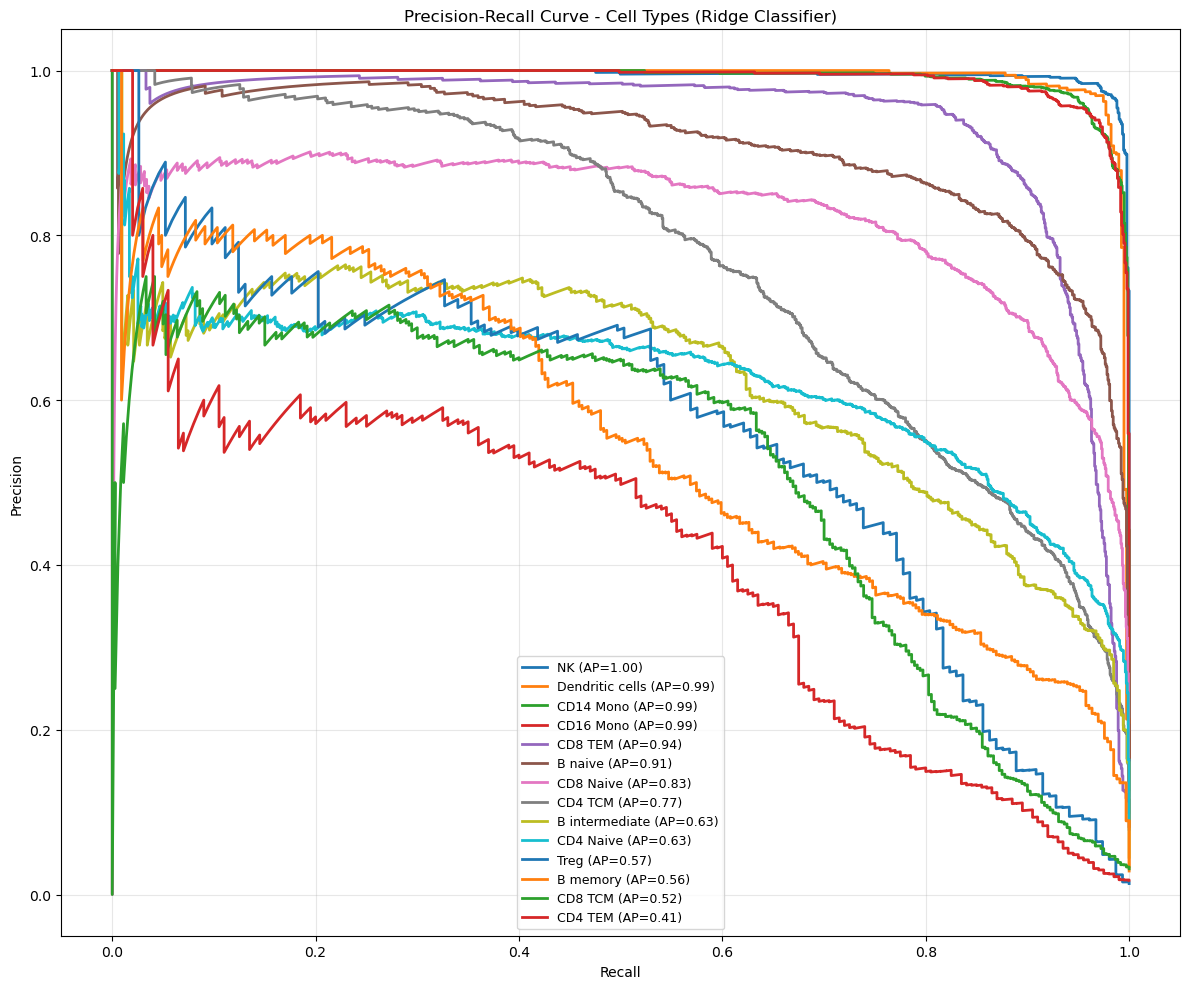

In [23]:
# Precision-Recall Curves, one per cell type
plt.figure(figsize=(12, 10))

pr_results = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_proba_ridge[:, i])
    ap_score = average_precision_score(y_val_bin[:, i], y_val_proba_ridge[:, i])
    class_name = label_encoder.classes_[i]
    pr_results.append((ap_score, class_name, recall, precision))

pr_results.sort(key=lambda x: x[0], reverse=True)

for ap_score, class_name, recall, precision in pr_results:
    plt.plot(recall, precision, lw=2, label=f"{class_name} (AP={ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Cell Types (Ridge Classifier)")
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "pr_curve_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

Comparing the ROC and Precision-Recall curves reveals a discrepancy that's especially informative given the class imbalance in this dataset. By AUC, most classes look strong — even Treg (0.97), CD8 TCM (0.93), and CD4 TEM (0.94) appear to have solid discriminative power. But Average Precision tells a different story: Treg (AP=0.57), CD8 TCM (AP=0.52), B memory (AP=0.56), and CD4 TEM (AP=0.41) all rank at the bottom, consistent with the low-precision, high-false-positive pattern already observed in the confusion matrix. This divergence is expected on imbalanced data — ROC-AUC is computed against a very large negative class, making even a mediocre classifier look strong, while AP is sensitive specifically to how often positive predictions are correct. For this dataset, Average Precision is the more trustworthy indicator of real-world reliability for the minority classes.

Generating UMAP embedding for visualization...


/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


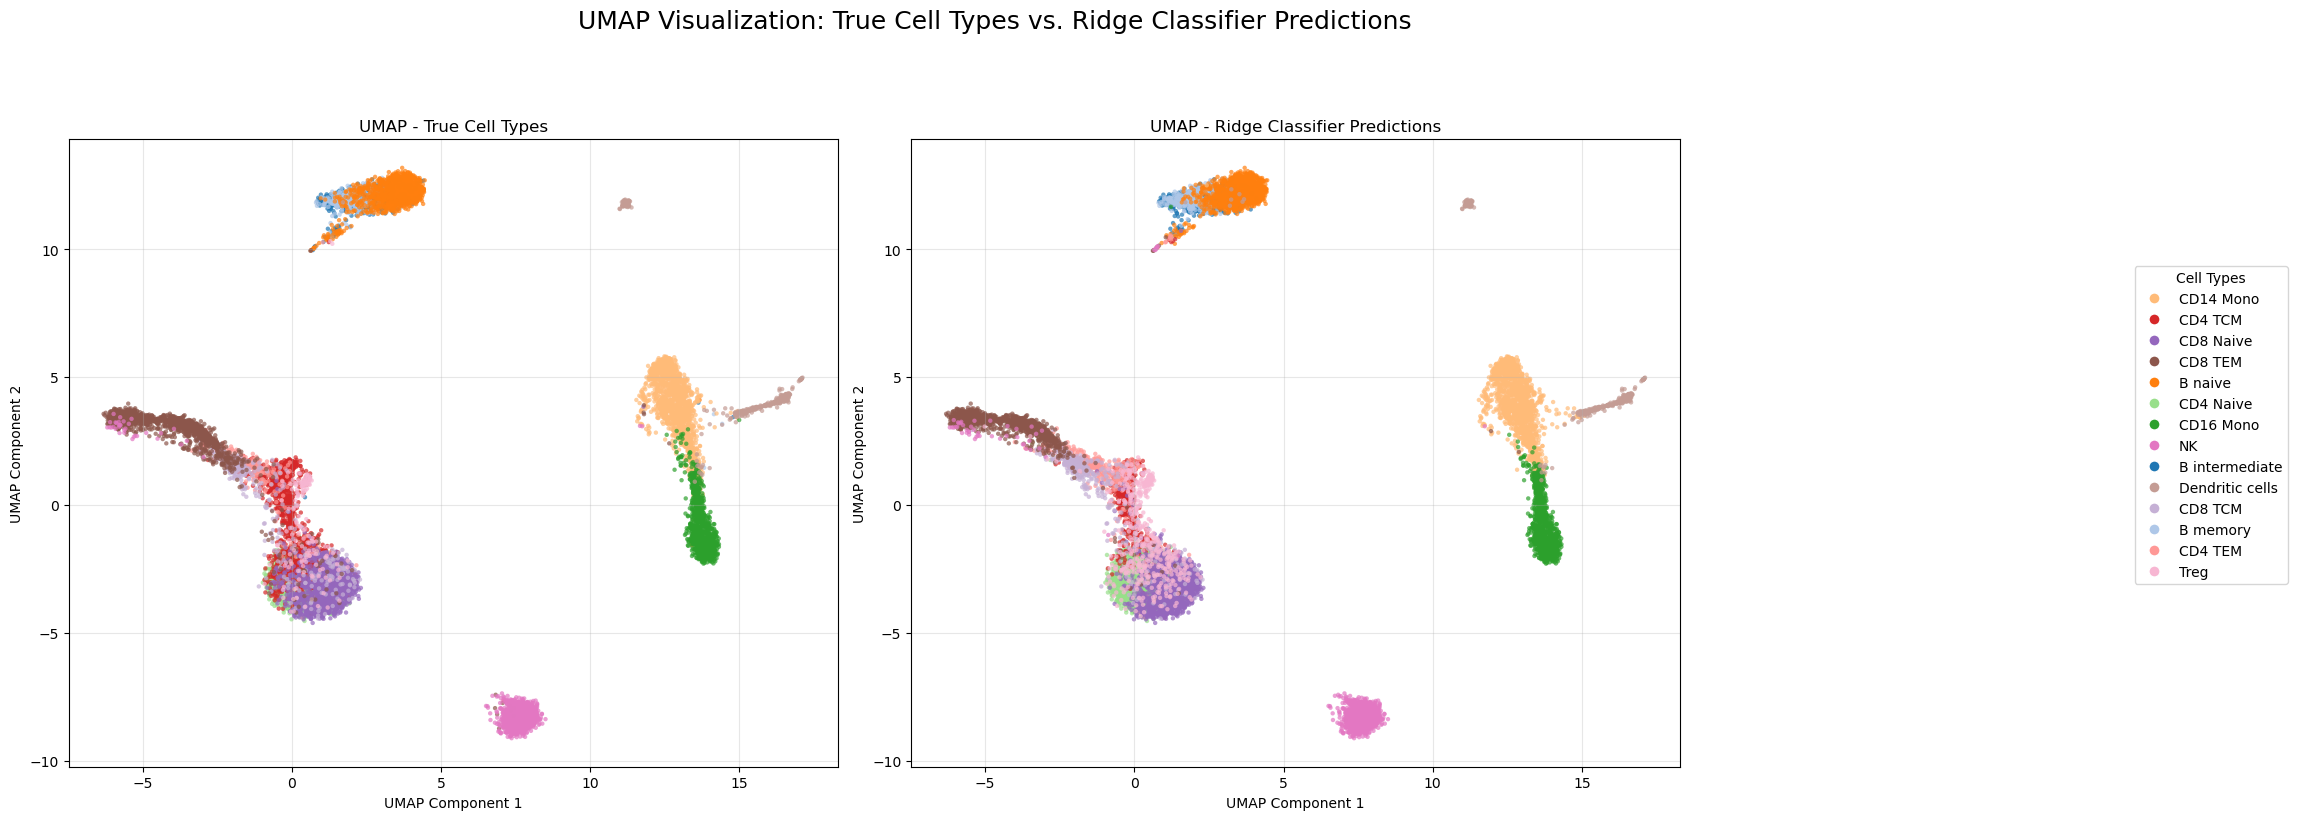

In [24]:
print("Generating UMAP embedding for visualization...")
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=RAND_SEED)
X_val_umap = reducer.fit_transform(X_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

unique_cell_types = np.unique(meta_val["CellType"])
n_colors = len(unique_cell_types)
color_palette = sns.color_palette("tab20", n_colors=min(20, n_colors))
color_palette += sns.color_palette("tab20b", n_colors=max(0, n_colors - 20))
color_dict = {cell_type: color_palette[i % len(color_palette)] for i, 
              cell_type in enumerate(unique_cell_types)}

# Plot 1: True Cell Types
for cell_type in unique_cell_types:
    mask = (meta_val["CellType"] == cell_type)
    ax1.scatter(X_val_umap[mask, 0], 
                X_val_umap[mask, 1], 
                s=10, 
                color=color_dict[cell_type], 
                label=cell_type, 
                alpha=0.7, 
                edgecolor="none")
ax1.set_title("UMAP - True Cell Types")
ax1.set_xlabel("UMAP Component 1")
ax1.set_ylabel("UMAP Component 2")
ax1.grid(alpha=0.3)

# Plot 2: Ridge Classifier Predictions
predicted_cell_types = label_encoder.inverse_transform(y_val_pred_ridge)
for cell_type in unique_cell_types:
    mask = (predicted_cell_types == cell_type)
    ax2.scatter(X_val_umap[mask, 0], 
                X_val_umap[mask, 1], 
                s=10, 
                color=color_dict[cell_type], 
                label=cell_type, 
                alpha=0.7, 
                edgecolor="none")
ax2.set_title("UMAP - Ridge Classifier Predictions")
ax2.set_xlabel("UMAP Component 1")
ax2.set_ylabel("UMAP Component 2")
ax2.grid(alpha=0.3)

# Legend for all cell types, ordered by abundance (largest first)
cell_type_counts = {ct: (meta_val["CellType"] == ct).sum() for ct in unique_cell_types}
ordered_cell_types = sorted(unique_cell_types, key=lambda ct: cell_type_counts[ct], reverse=True)

handles = [plt.Line2D([0], [0], 
                      marker="o", 
                      color="w", 
                      markerfacecolor=color_dict[ct], 
                      markersize=8) for ct in ordered_cell_types]
labels = list(ordered_cell_types)

fig.legend(handles, 
           labels, 
           loc="center right", 
           title="Cell Types", 
           bbox_to_anchor=(1.15, 0.5), 
           ncol=1, 
           fontsize=10)

plt.suptitle("UMAP Visualization: True Cell Types vs. Ridge Classifier Predictions", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.savefig(os.path.join(PLOT_DIR, "umap_ridge_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

The UMAP comparison confirms the confusion matrix findings visually. Well-separated islands in true-label space (B naive/intermediate/memory, NK, CD14/CD16 Mono, Dendritic cells) remain clean in the predicted-label panel, consistent with their high F1 scores. The elongated lower-left arm, containing CD8 TEM, CD8 Naive, CD4 TCM, CD4 TEM, Treg, CD8 TCM, and CD4 Naive, already shows substantial color intermixing in the true-label panel itself, reflecting real transcriptional similarity between these T-cell subsets rather than a modeling failure alone. The predicted-label panel mirrors this same mixing pattern closely, indicating the Ridge Classifier's errors are concentrated exactly where the underlying biology makes clean separation genuinely difficult, not in regions that are cleanly separated in truth but scrambled by the model.